# Section A — Question 1 Notebook  
**Question:** How does `BEV_Share` growth over time (2018–2025) correlate with `Units_Sold` and `Revenue_EUR` across different regions, and which region shows the strongest transition toward electrification?


The raw dataset is at a **model-level granularity** for each `Year × Month × Region × Model`.

However, this question asks about:
- **BEV adoption over time**
- **regional comparisons**
- relationships with total **sales** and **revenue**

That means we should aggregate to a **region-time level** before analysis.

### Aggregation choices
- `Units_Sold` → **sum**
- `Revenue_EUR` → **sum**
- `BEV_Share` → **mean**
  - because it is a share / proportion indicator at the region-time level

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make plots readable
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Try to locate the CSV in common locations
candidate_paths = [
    Path("bmw_global_sales_2018_2025.csv"),
    Path("./bmw_global_sales_2018_2025.csv"),
    Path("/mnt/data/bmw_global_sales_2018_2025.csv"),
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError(
        "Could not find 'bmw_global_sales_2018_2025.csv'. "
        "Place the CSV in the same folder as this notebook, or update candidate_paths."
    )

df = pd.read_csv(csv_path)
print(f"Loaded: {csv_path}")
print(df.shape)
df.head()

Loaded: bmw_global_sales_2018_2025.csv
(3072, 11)


,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


## 1. Quick structure check
We first inspect the schema and verify the data types / missing values.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3072 entries, 0 to 3071
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              3072 non-null   int64  
 1   Month             3072 non-null   int64  
 2   Region            3072 non-null   object 
 3   Model             3072 non-null   object 
 4   Units_Sold        3072 non-null   int64  
 5   Avg_Price_EUR     3072 non-null   int64  
 6   Revenue_EUR       3072 non-null   int64  
 7   BEV_Share         3072 non-null   float64
 8   Premium_Share     3072 non-null   float64
 9   GDP_Growth        3072 non-null   float64
 10  Fuel_Price_Index  3072 non-null   float64
dtypes: float64(4), int64(5), object(2)
memory usage: 264.1+ KB


In [3]:
df.isna().sum()

Year                0
Month               0
Region              0
Model               0
Units_Sold          0
Avg_Price_EUR       0
Revenue_EUR         0
BEV_Share           0
Premium_Share       0
GDP_Growth          0
Fuel_Price_Index    0
dtype: int64

## 2. Confirm the granularity issue
This check shows that each `Year × Month × Region` contains multiple rows because the data is split by `Model`.

In [4]:
granularity_check = (
    df.groupby(["Year", "Month", "Region"])
      .size()
      .reset_index(name="rows_per_group")
      .sort_values("rows_per_group", ascending=False)
)

granularity_check.head(10)

,Year,Month,Region,rows_per_group
0,2018,1,China,8
1,2018,1,Europe,8
262,2023,6,RestOfWorld,8
261,2023,6,Europe,8
260,2023,6,China,8
259,2023,5,USA,8
258,2023,5,RestOfWorld,8
257,2023,5,Europe,8
256,2023,5,China,8
255,2023,4,USA,8


## 3. Aggregate to region-year level
For the main question, a **yearly regional view** makes the trend easier to interpret.

In [5]:
region_year = (
    df.groupby(["Year", "Region"], as_index=False)
      .agg(
          Units_Sold=("Units_Sold", "sum"),
          Revenue_EUR=("Revenue_EUR", "sum"),
          BEV_Share=("BEV_Share", "mean")
      )
      .sort_values(["Region", "Year"])
)

region_year.head(12)

,Year,Region,Units_Sold,Revenue_EUR,BEV_Share
0,2018,China,675593,43906098288,0.020177
4,2019,China,705400,45538083738,0.043302
8,2020,China,758036,48298566836,0.070115
12,2021,China,804804,51733254067,0.094469
16,2022,China,767549,48894314065,0.119677
20,2023,China,817300,52239601754,0.145115
24,2024,China,840879,53989799850,0.169396
28,2025,China,887189,57155301885,0.194177
1,2018,Europe,706759,45228201998,0.021406
5,2019,Europe,643808,40930362440,0.045927


## 4. Regional BEV adoption over time
This chart shows how electrification evolves from 2018 to 2025 in each region.

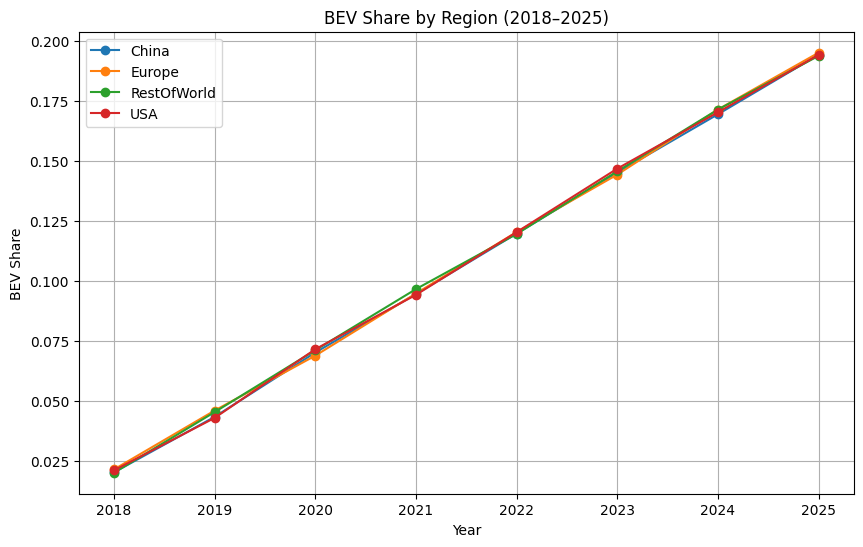

In [6]:
fig, ax = plt.subplots()
for region, grp in region_year.groupby("Region"):
    ax.plot(grp["Year"], grp["BEV_Share"], marker="o", label=region)

ax.set_title("BEV Share by Region (2018–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("BEV Share")
ax.legend()
plt.show()

## 5. Units sold over time by region
This helps interpret whether higher BEV penetration coincides with stronger or weaker volume performance.

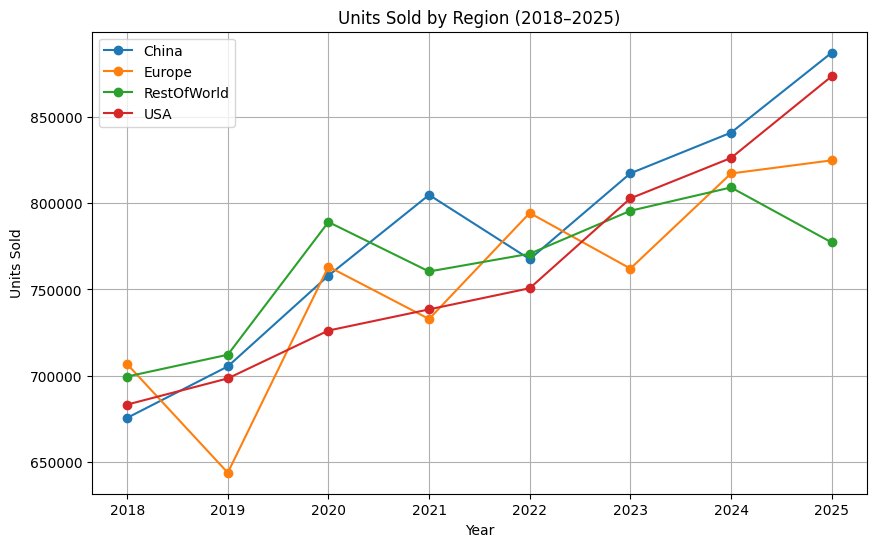

In [7]:
fig, ax = plt.subplots()
for region, grp in region_year.groupby("Region"):
    ax.plot(grp["Year"], grp["Units_Sold"], marker="o", label=region)

ax.set_title("Units Sold by Region (2018–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Units Sold")
ax.legend()
plt.show()

## 6. Revenue over time by region
Revenue can move differently from volume, especially if average vehicle prices shift upward with electrification.

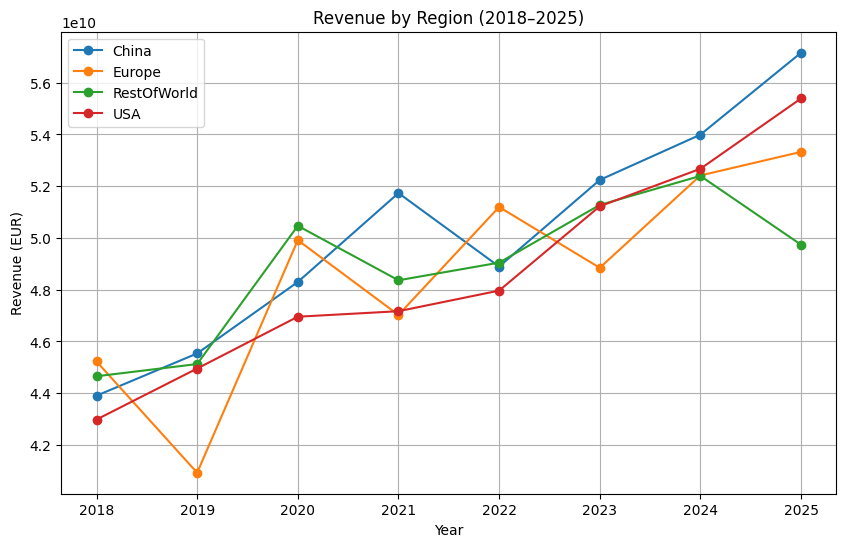

In [8]:
fig, ax = plt.subplots()
for region, grp in region_year.groupby("Region"):
    ax.plot(grp["Year"], grp["Revenue_EUR"], marker="o", label=region)

ax.set_title("Revenue by Region (2018–2025)")
ax.set_xlabel("Year")
ax.set_ylabel("Revenue (EUR)")
ax.legend()
plt.show()

## 7. Correlation analysis by region
We now compute the correlation of:
- `BEV_Share` vs `Units_Sold`
- `BEV_Share` vs `Revenue_EUR`

This is done **within each region across years**.

In [9]:
corr_rows = []

for region, grp in region_year.groupby("Region"):
    corr_units = grp["BEV_Share"].corr(grp["Units_Sold"])
    corr_revenue = grp["BEV_Share"].corr(grp["Revenue_EUR"])
    bev_2018 = grp.loc[grp["Year"] == 2018, "BEV_Share"].iloc[0]
    bev_2025 = grp.loc[grp["Year"] == 2025, "BEV_Share"].iloc[0]
    abs_change = bev_2025 - bev_2018
    pct_change = (bev_2025 / bev_2018 - 1) if bev_2018 != 0 else np.nan

    corr_rows.append({
        "Region": region,
        "Corr_BEV_vs_Units": corr_units,
        "Corr_BEV_vs_Revenue": corr_revenue,
        "BEV_2018": bev_2018,
        "BEV_2025": bev_2025,
        "BEV_Absolute_Change": abs_change,
        "BEV_Relative_Growth": pct_change
    })

corr_df = pd.DataFrame(corr_rows).sort_values("BEV_Absolute_Change", ascending=False)
corr_df

,Region,Corr_BEV_vs_Units,Corr_BEV_vs_Revenue,BEV_2018,BEV_2025,BEV_Absolute_Change,BEV_Relative_Growth
0,China,0.958166,0.952624,0.020177,0.194177,0.174000,8.623645
2,RestOfWorld,0.794600,0.797395,0.020021,0.193729,0.173708,8.676379
1,Europe,0.843757,0.815030,0.021406,0.195042,0.173635,8.111436
3,USA,0.978516,0.980821,0.021010,0.194156,0.173146,8.240952


## 8. Scatter plots for interpretation
These plots show the relationship between electrification and performance across regions.

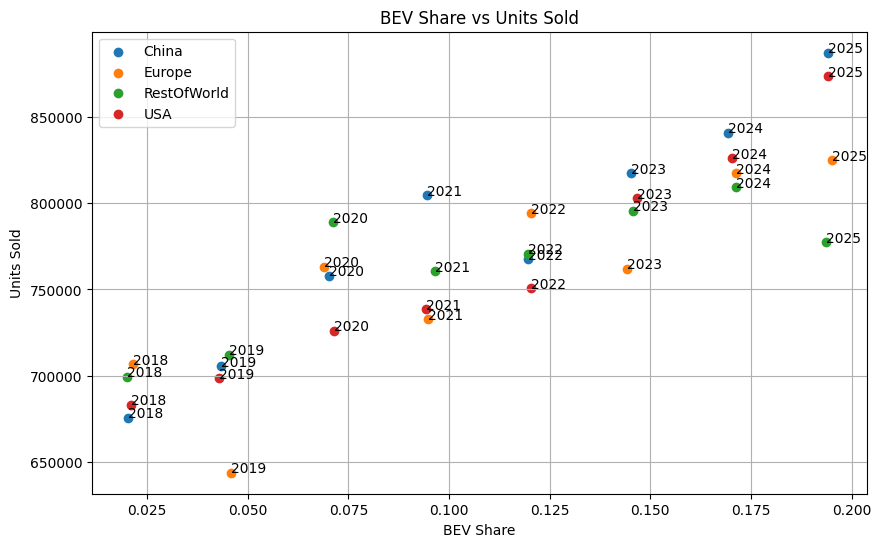

In [10]:
fig, ax = plt.subplots()
for region, grp in region_year.groupby("Region"):
    ax.scatter(grp["BEV_Share"], grp["Units_Sold"], label=region)
    for _, row in grp.iterrows():
        ax.annotate(str(int(row["Year"])), (row["BEV_Share"], row["Units_Sold"]))

ax.set_title("BEV Share vs Units Sold")
ax.set_xlabel("BEV Share")
ax.set_ylabel("Units Sold")
ax.legend()
plt.show()

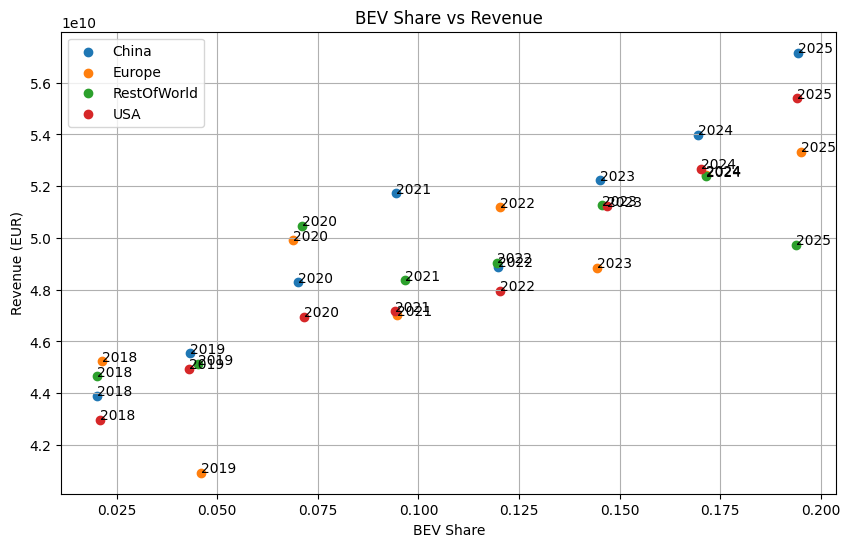

In [11]:
fig, ax = plt.subplots()
for region, grp in region_year.groupby("Region"):
    ax.scatter(grp["BEV_Share"], grp["Revenue_EUR"], label=region)
    for _, row in grp.iterrows():
        ax.annotate(str(int(row["Year"])), (row["BEV_Share"], row["Revenue_EUR"]))

ax.set_title("BEV Share vs Revenue")
ax.set_xlabel("BEV Share")
ax.set_ylabel("Revenue (EUR)")
ax.legend()
plt.show()

## 9. Identify the strongest transition toward electrification
We define "strongest transition" primarily as the **largest absolute increase in `BEV_Share` from 2018 to 2025**.

This is usually the clearest interpretation for a share-based adoption metric.

In [13]:
region_month = (
    df.groupby(["Year", "Month", "Region"], as_index=False)
      .agg(
          Units_Sold=("Units_Sold", "sum"),
          Revenue_EUR=("Revenue_EUR", "sum"),
          BEV_Share=("BEV_Share", "mean")
      )
      .sort_values(["Region", "Year", "Month"])
)

region_month.head()

,Year,Month,Region,Units_Sold,Revenue_EUR,BEV_Share
0,2018,1,China,54742,3565766365,0.016750
4,2018,2,China,39572,2545481878,0.024875
8,2018,3,China,59817,3983957987,0.025000
12,2018,4,China,69078,4559884863,0.020125
16,2018,5,China,57394,3834612018,0.019250


## 10. Final interpretation

> BEV adoption increases steadily across all regions from 2018 to 2025, indicating a broad transition toward electrification.  Because the raw dataset mixes model-level rows with region-level share indicators, aggregation was necessary before performing meaningful trend and correlation analysis.
> After aggregating the data to the regional time-series level, the relationship between `BEV_Share` and business performance appears to be region-specific.  
> In some regions, higher BEV penetration aligns with stronger `Revenue_EUR`, suggesting that electrification may be associated with higher-value sales.  
> The relationship with `Units_Sold` is more mixed, implying that EV adoption does not always translate directly into higher volume.  
> Based on the change in `BEV_Share` between 2018 and 2025, **China** shows the strongest transition toward electrification.